# 📊 CareerLens AI

## Notebook 01 — Dataset Exploration

### Objective

The purpose of this notebook is to understand the resume dataset before any preprocessing or model development.

### Tasks

- Load the dataset
- Inspect its structure
- Check missing values
- Check duplicate records
- Explore class distribution
- Analyze resume lengths
- Document engineering observations

---

**Author:** Anushka Das

**Project:** CareerLens AI

**Notebook:** 01_Dataset_Exploration.ipynb

**Version:** 1.0

In [1]:
# ==========================================================
# Import Required Libraries
# ==========================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import plotly.express as px

# Display Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 200)

print("Libraries imported successfully.")

Libraries imported successfully.


# 📂 Load Dataset

In [3]:
# ==========================================================
# Load Dataset
# ==========================================================

dataset_path = "../datasets/raw/Resume.csv"

df = pd.read_csv(dataset_path)

print("Datset loaded successfully.")


Datset loaded successfully.


# 👀 First Look at the Dataset

In [4]:
# Display first five rows

df.head()

,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\n\nHR ADMINISTRATOR Summary Dedicated Customer Service Manager with 15+ years of experience in Hospitality and Customer Service Management. ...,"<div class=""fontsize fontface vmargins hmargins linespacing pagesize"" id=""document""> <div class=""section firstsection"" id=""SECTION_NAME500375979"" style=""\n padding-top:0px;\n ""> <div class...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS Summary Versatile media professional with background in Communications, Marketing, Human Resources and Technology. Experience 09/201...","<div class=""fontsize fontface vmargins hmargins linespacing pagesize"" id=""document""> <div class=""section firstsection"" id=""SECTION_NAME911808366"" style=""padding-top:0px;""> <div class=""paragraph PA...",HR
2,33176873,"HR DIRECTOR Summary Over 20 years experience in recruiting, 15 plus years in Human Resources Executive Management, 5 years of HRIS development and maintenance 4 years work...","<div class=""fontsize fontface vmargins hmargins linespacing pagesize"" id=""document""> <div class=""section firstsection"" id=""SECTION_NAME1008511259"" style=""padding-top:0px;""> <div class=""paragraph P...",HR
3,27018550,"HR SPECIALIST Summary Dedicated, Driven, and Dynamic with over 20 years of customer service expertise. Motivated to maintain customer satisfaction and contribute to company succe...","<div class=""fontsize fontface vmargins hmargins linespacing pagesize"" id=""document""> <div class=""section firstsection"" id=""SECTION_NAME992636658"" style=""padding-top:0px;""> <div class=""paragraph PA...",HR
4,17812897,HR MANAGER Skill Highlights HR SKILLS HR Department Startup Three New Organization Startups Employment Law FMLA/ADA/EEO/WC Mediation & Advocacy HR Policies & Proce...,"<div class=""fontsize fontface vmargins hmargins linespacing pagesize"" id=""document""> <div class=""section firstsection"" id=""SECTION_NAME666809417"" style=""padding-top:0px;""> <div class=""paragraph PA...",HR


In [5]:
# Shape of the dataset 

print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

Rows    : 2484
Columns : 4


In [6]:
# Columns names

df.columns

Index(['ID', 'Resume_str', 'Resume_html', 'Category'], dtype='str')

# 🔍 Data Quality Assessment

Before preprocessing the dataset, we need to evaluate its quality.

We'll check:

- Missing values
- Duplicate records
- Data types
- Memory usage
- Category distribution

In [16]:
# ==========================================================
# Dataset Information
# ==========================================================

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2484 entries, 0 to 2483
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   ID           2484 non-null   int64
 1   Resume_str   2484 non-null   str  
 2   Resume_html  2484 non-null   str  
 3   Category     2484 non-null   str  
dtypes: int64(1), str(3)
memory usage: 77.8 KB


# ❓ Missing Values Analysis

In [8]:
# ==========================================================
# Missing Values
# ==========================================================

missing = df.isnull().sum()

missing

ID             0
Resume_str     0
Resume_html    0
Category       0
dtype: int64

In [9]:
# Missing value percentage

missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage

ID             0.0
Resume_str     0.0
Resume_html    0.0
Category       0.0
dtype: float64

# 📄 Duplicate Records

In [10]:
# ==========================================================
# Duplicate Records
# ==========================================================

duplicates = df.duplicated().sum()

print(f"Duplicate Rows : {duplicates}")

Duplicate Rows : 0


# 📊 Category Distribution

In [11]:
# ==========================================================
# Number of Resume Categories
# ==========================================================

df["Category"].nunique()

24

In [12]:
# List Categories
sorted(df["Category"].unique())

['ACCOUNTANT',
 'ADVOCATE',
 'AGRICULTURE',
 'APPAREL',
 'ARTS',
 'AUTOMOBILE',
 'AVIATION',
 'BANKING',
 'BPO',
 'BUSINESS-DEVELOPMENT',
 'CHEF',
 'CONSTRUCTION',
 'CONSULTANT',
 'DESIGNER',
 'DIGITAL-MEDIA',
 'ENGINEERING',
 'FINANCE',
 'FITNESS',
 'HEALTHCARE',
 'HR',
 'INFORMATION-TECHNOLOGY',
 'PUBLIC-RELATIONS',
 'SALES',
 'TEACHER']

In [13]:
# Category Counts

category_counts = df["Category"].value_counts()

category_counts

Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
ADVOCATE                  118
CHEF                      118
FINANCE                   118
ENGINEERING               118
ACCOUNTANT                118
FITNESS                   117
AVIATION                  117
SALES                     116
HEALTHCARE                115
CONSULTANT                115
BANKING                   115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64

# 📈 Category Distribution Visualization

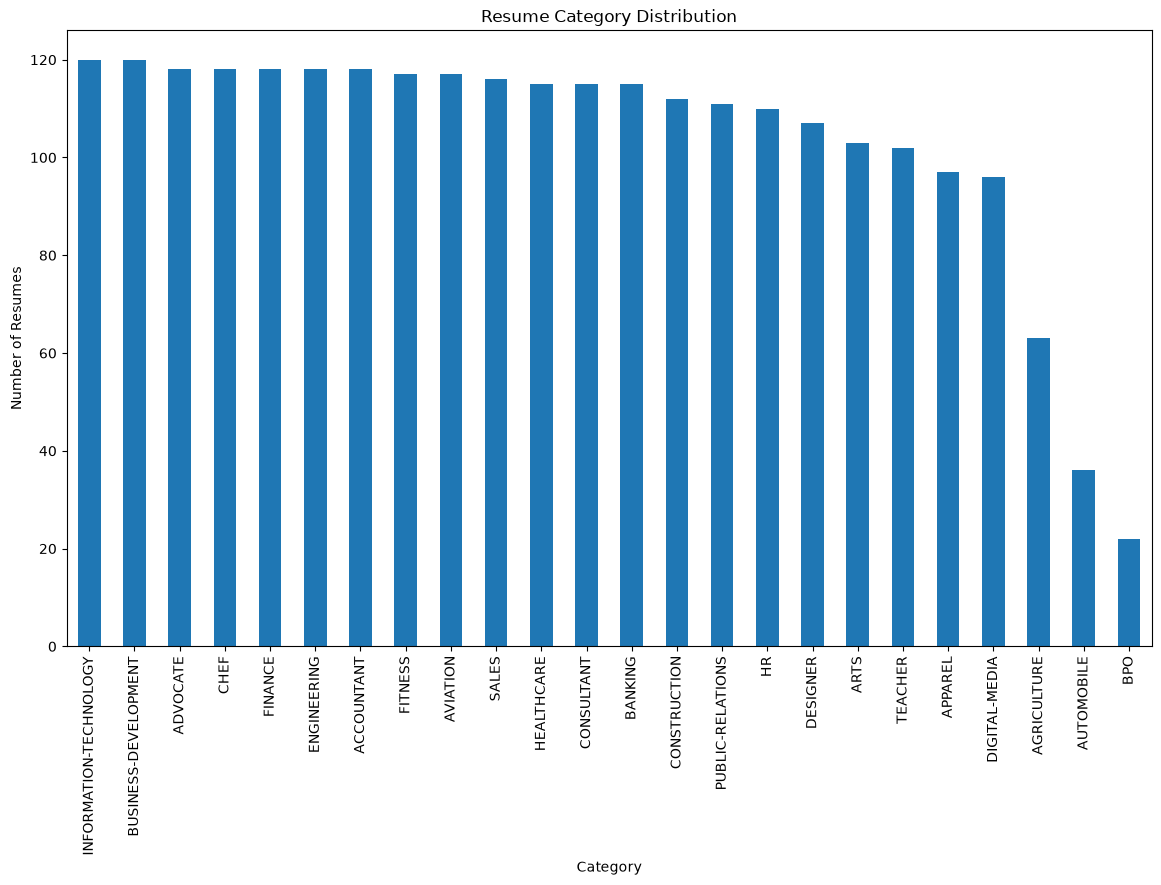

In [14]:
plt.figure(figsize=(14,8))

category_counts.plot(kind="bar")

plt.title("Resume Category Distribution")

plt.xlabel("Category")

plt.ylabel("Number of Resumes")

plt.xticks(rotation=90)

plt.show()

In [15]:
fig = px.bar(
    category_counts,
    x=category_counts.index,
    y=category_counts.values,
    title="Resume Categories"
)

fig.show()

# 🧠 Engineering Observations

### Dataset Quality

- The dataset contains **2,484 resumes** across **24 job categories**.
- No missing values were found in any column.
- No duplicate records were detected.
- The dataset is clean and suitable for machine learning without major data cleaning.

### Category Distribution

- The dataset is relatively balanced.
- Most categories contain between **100–120 resumes**.
- A few categories such as **BPO**, **Automobile**, and **Agriculture** contain fewer samples.
- Overall, the class imbalance is minimal and acceptable for Version 1.

### Data Structure

The dataset contains four columns:

- **ID** – Unique identifier for each resume.
- **Resume_str** – Plain text version of the resume.
- **Resume_html** – HTML representation of the resume.
- **Category** – Target label used for classification.

### Engineering Decision

For model training, the **Resume_str** column will be used because it contains clean textual information suitable for Natural Language Processing (NLP). The **Resume_html** column will be inspected later to determine whether additional formatting information is useful.

## Observations

### Dataset Size

- The dataset contains 2,484 resumes.
- There are 4 columns.

### Missing Values

- No missing values were found.
- All columns are complete and ready for preprocessing.

### Duplicate Records

- No duplicate records were found.

### Categories

- The dataset contains 24 resume categories.
- Most categories contain around 100–120 resumes.
- A few categories such as BPO and Automobile have fewer samples.

### Initial Conclusion

- The dataset is clean.
- No missing values or duplicate records exist.
- The class distribution is relatively balanced.
- The dataset is suitable for NLP preprocessing and machine learning.

# 📏 Resume Length Analysis

In this section, we analyze resume length using character count and word count.

This helps us understand how much text the model will process and whether some resumes are unusually short or unusually long.

In [17]:
# ==========================================================
# Resume Length Analysis
# ==========================================================

df["character_count"] = df["Resume_str"].apply(len)
df["word_count"] = df["Resume_str"].apply(lambda text: len(str(text).split()))

df[["Resume_str", "character_count", "word_count"]].head()

,Resume_str,character_count,word_count
0,HR ADMINISTRATOR/MARKETING ASSOCIATE\n\nHR ADMINISTRATOR Summary Dedicated Customer Service Manager with 15+ years of experience in Hospitality and Customer Service Management. ...,5442,674
1,"HR SPECIALIST, US HR OPERATIONS Summary Versatile media professional with background in Communications, Marketing, Human Resources and Technology. Experience 09/201...",5572,708
2,"HR DIRECTOR Summary Over 20 years experience in recruiting, 15 plus years in Human Resources Executive Management, 5 years of HRIS development and maintenance 4 years work...",7720,1017
3,"HR SPECIALIST Summary Dedicated, Driven, and Dynamic with over 20 years of customer service expertise. Motivated to maintain customer satisfaction and contribute to company succe...",2855,379
4,HR MANAGER Skill Highlights HR SKILLS HR Department Startup Three New Organization Startups Employment Law FMLA/ADA/EEO/WC Mediation & Advocacy HR Policies & Proce...,9172,1206


In [18]:
# Summary statistics

df[["character_count", "word_count"]].describe()

,character_count,word_count
count,2484.000000,2484.000000
mean,6295.308776,811.325684
std,2769.251458,371.006906
min,21.000000,0.000000
25%,5160.000000,651.000000
50%,5886.500000,757.000000
75%,7227.250000,933.000000
max,38842.000000,5190.000000


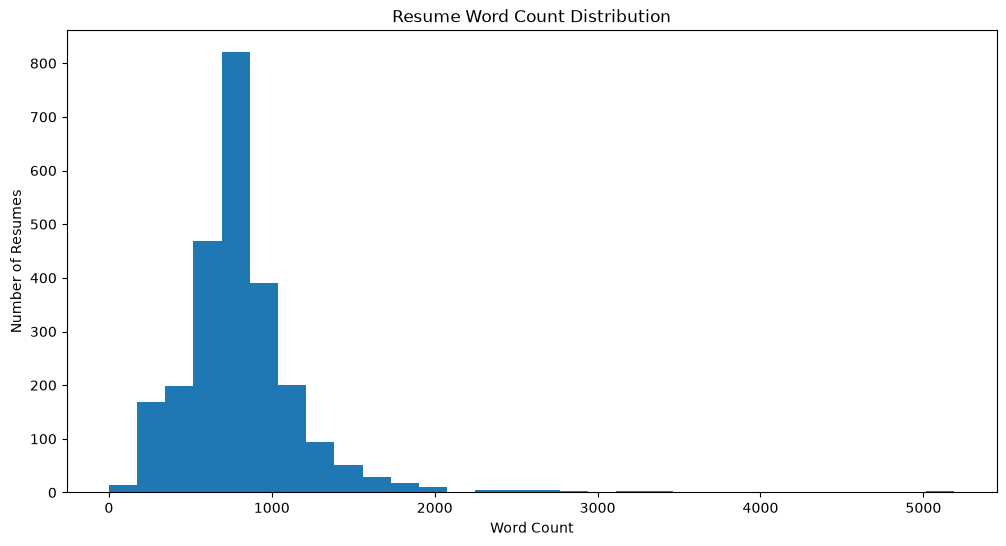

In [19]:
# Word count distribution

plt.figure(figsize=(12, 6))
plt.hist(df["word_count"], bins=30)
plt.title("Resume Word Count Distribution")
plt.xlabel("Word Count")
plt.ylabel("Number of Resumes")
plt.show()

In [20]:
# Interactive word count distribution

fig = px.histogram(
    df,
    x="word_count",
    nbins=30,
    title="Resume Word Count Distribution"
)

fig.show()

# 🌐 HTML Column Inspection

The dataset contains both plain text resumes and HTML resumes.

For Version 1, we will use `Resume_str` for model training because it is simpler and directly usable for NLP preprocessing.

In [21]:
# Compare plain text and HTML version for one resume

sample_index = 0

print("Plain Text Resume:")
print(df.loc[sample_index, "Resume_str"][:1000])

print("\n" + "="*80 + "\n")

print("HTML Resume:")
print(df.loc[sample_index, "Resume_html"][:1000])

Plain Text Resume:
         HR ADMINISTRATOR/MARKETING ASSOCIATE

HR ADMINISTRATOR       Summary     Dedicated Customer Service Manager with 15+ years of experience in Hospitality and Customer Service Management.   Respected builder and leader of customer-focused teams; strives to instill a shared, enthusiastic commitment to customer service.         Highlights         Focused on customer satisfaction  Team management  Marketing savvy  Conflict resolution techniques     Training and development  Skilled multi-tasker  Client relations specialist           Accomplishments      Missouri DOT Supervisor Training Certification  Certified by IHG in Customer Loyalty and Marketing by Segment   Hilton Worldwide General Manager Training Certification  Accomplished Trainer for cross server hospitality systems such as    Hilton OnQ  ,   Micros    Opera PMS   , Fidelio    OPERA    Reservation System (ORS) ,   Holidex    Completed courses and seminars in customer service, sales strategies, inventory 

# 🧹 Text Cleaning Strategy

Before training a machine learning model, resume text must be cleaned.

For Version 1, our preprocessing strategy will include:

- Lowercasing text
- Removing URLs
- Removing email addresses
- Removing phone-number-like patterns
- Removing special characters
- Removing extra spaces

Later versions may include lemmatization, named entity recognition, skill extraction, and transformer-based embeddings.

In [ ]:
import re

def clean_resume(text):
    """
    Clean resume text for NLP preprocessing.
    """
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"\S+@\S+", " ", text)
    text = re.sub(r"\+?\d[\d\s()-]{8,}\d", " ", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

SyntaxError: invalid syntax (1505958604.py, line 10)

In [ ]:
sample_resume = df.loc[0, "Resume_str"]

print("Before Cleaning:")
print(sample_resume[:700])

print("\n" + "="*80 + "\n")

print("After Cleaning:")
print(clean_resume(sample_resume)[:700])

Before Cleaning:
         HR ADMINISTRATOR/MARKETING ASSOCIATE

HR ADMINISTRATOR       Summary     Dedicated Customer Service Manager with 15+ years of experience in Hospitality and Customer Service Management.   Respected builder and leader of customer-focused teams; strives to instill a shared, enthusiastic commitment to customer service.         Highlights         Focused on customer satisfaction  Team management  Marketing savvy  Conflict resolution techniques     Training and development  Skilled multi-tasker  Client relations specialist           Accomplishments      Missouri DOT Supervisor Training Certification  Certified by IHG in Customer Loyalty and Marketing by Segment   Hilton Worldwide General 


After Cleaning:
hr administrator marketing associate hr administrator summary dedicated customer service manager with years of experience in hospitality and customer service management respected builder and leader of customer focused teams strives to instill a shared enthusiastic

In [24]:
# After cleaning function

df["cleaned_resume"] = df["Resume_str"].apply(clean_resume)

df[["Resume_str", "cleaned_resume"]].head()

,Resume_str,cleaned_resume
0,HR ADMINISTRATOR/MARKETING ASSOCIATE\n\nHR ADMINISTRATOR Summary Dedicated Customer Service Manager with 15+ years of experience in Hospitality and Customer Service Management. ...,hr administrator marketing associate hr administrator summary dedicated customer service manager with years of experience in hospitality and customer service management respected builder and leade...
1,"HR SPECIALIST, US HR OPERATIONS Summary Versatile media professional with background in Communications, Marketing, Human Resources and Technology. Experience 09/201...",hr specialist us hr operations summary versatile media professional with background in communications marketing human resources and technology experience to current hr specialist us hr operations ...
2,"HR DIRECTOR Summary Over 20 years experience in recruiting, 15 plus years in Human Resources Executive Management, 5 years of HRIS development and maintenance 4 years work...",hr director summary over years experience in recruiting plus years in human resources executive management years of hris development and maintenance years working in a healthcare enviroment skills...
3,"HR SPECIALIST Summary Dedicated, Driven, and Dynamic with over 20 years of customer service expertise. Motivated to maintain customer satisfaction and contribute to company succe...",hr specialist summary dedicated driven and dynamic with over years of customer service expertise motivated to maintain customer satisfaction and contribute to company success with an emphasis in p...
4,HR MANAGER Skill Highlights HR SKILLS HR Department Startup Three New Organization Startups Employment Law FMLA/ADA/EEO/WC Mediation & Advocacy HR Policies & Proce...,hr manager skill highlights hr skills hr department startup three new organization startups employment law fmla ada eeo wc mediation advocacy hr policies procedures staff recruitment retention sal...


# ✅ Day 3 Final Observations

## What we learned

- The dataset contains 2,484 resumes across 24 categories.
- There are no missing values.
- There are no duplicate records.
- The class distribution is mostly balanced, with a few smaller categories.
- `Resume_str` will be used for Version 1 model training.
- `Resume_html` may be useful in future versions.
- Resume text needs cleaning before feature extraction.
- A basic resume cleaning function was created.

## Engineering Decision

For Version 1, CareerLens AI will use:

- `Resume_str` as the main input text column.
- `Category` as the target label.
- Basic regex-based text preprocessing.
- TF-IDF features in the next phase.

## Next Step

The next notebook will focus on preprocessing and feature engineering.